In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display

In [2]:
wordpress_report    = "Wordpress Summary/IncrementalTesting/InjectCache/Wordpress Report - Incremental Inject Summary.csv"
ghost_report = "Ghost Summary/IncrementalTesting/InjectCache/Ghost Report - Incremental Inject Summary.csv"
drupal_report = "Drupal Summary/IncrementalTesting/InjectCache/Drupal Report - Incremental Inject Summary.csv"

wordpress = pd.read_csv(wordpress_report)
ghost = pd.read_csv(ghost_report)
drupal = pd.read_csv(drupal_report)

In [3]:
wordpress_avg = wordpress.iloc[-1:].copy()
ghost_avg = ghost.iloc[-1:].copy()
drupal_avg = drupal.iloc[-1:].copy()

wordpress_avg['website'] = 'WordPress'
ghost_avg['website'] = 'Ghost'
drupal_avg['website'] = 'Drupal'

comparison = pd.concat([wordpress_avg, ghost_avg, drupal_avg], ignore_index=True)

In [4]:
cols = ['website', 'avg_response (ms)', 'p95_response (ms)',  'avg_latency (ms)',
        'error_rate (%)', 'throughput (req/s)', 'cache bypass (%)', 'apdex']

result = comparison[cols].round(3)
result.to_csv("Assets Testing/Incremental/Inject Cache/Comparison Report - Incremental Inject.csv", index=False)

styled = (result.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

website,avg_response (ms),p95_response (ms),avg_latency (ms),error_rate (%),throughput (req/s),cache bypass (%),apdex
WordPress,5155.682,18985.800,4988.790,50.894,85.208,100.000,0.583
Ghost,3040.250,9083.340,2889.448,15.550,87.526,100.000,0.444
Drupal,1601.468,4351.450,1211.428,21.442,217.462,100.000,0.566


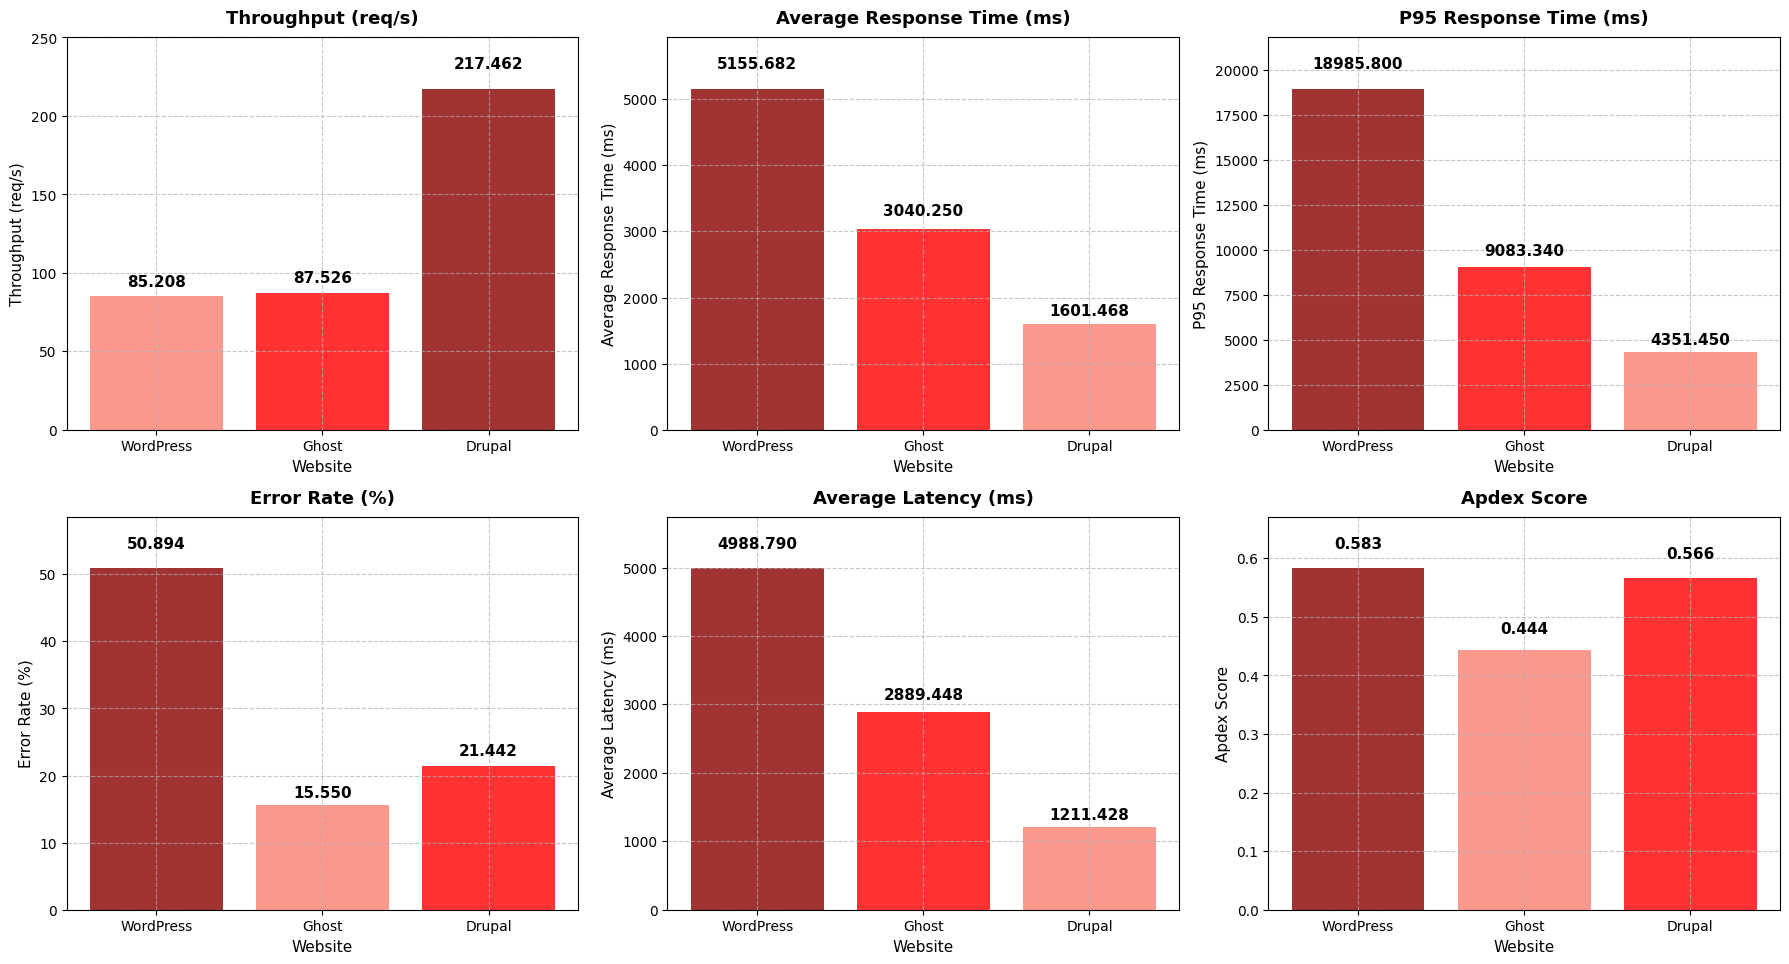

In [5]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

metrics = [
    ('throughput (req/s)', 'Throughput (req/s)'         ),
    ('avg_response (ms)',  'Average Response Time (ms)' ),
    ('p95_response (ms)',  'P95 Response Time (ms)'     ),
    ('error_rate (%)',     'Error Rate (%)'             ),
    ('avg_latency (ms)',   'Average Latency (ms)'       ),
    ('apdex',              'Apdex Score'                ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 3)

    values = result[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]

    bars = axs[row, col_idx].bar(result['website'], result[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = result[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Assets Testing/Incremental/Inject Cache/Comparison Report - Incremental Inject.png")
plt.show()

In [6]:
wordpress_result    = "Wordpress Summary/IncrementalTesting/InjectCache/Wordpress Result - Incremental Inject Summary.csv"
ghost_result = "Ghost Summary/IncrementalTesting/InjectCache/Ghost Result - Incremental Inject Summary.csv"
drupal_result = "Drupal Summary/IncrementalTesting/InjectCache/Drupal Result - Incremental Inject Summary.csv"

wordpress_result_monitor = pd.read_csv(wordpress_result)
ghost_result_monitor = pd.read_csv(ghost_result)
drupal_result_monitor = pd.read_csv(drupal_result)

In [7]:
wordpress_result_monitoring = wordpress_result_monitor.iloc[-1:].copy()
ghost_result_monitoring = ghost_result_monitor.iloc[-1:].copy()
drupal_result_monitoring = drupal_result_monitor.iloc[-1:].copy()

wordpress_result_monitoring['Website'] = 'WordPress'
ghost_result_monitoring['Website'] = 'Ghost'
drupal_result_monitoring['Website'] = 'Drupal'

result_comparison = pd.concat([wordpress_result_monitoring, ghost_result_monitoring, drupal_result_monitoring], ignore_index=True)

In [8]:
cols_result_monitoring = ['Website', 'Avg CPU (m)', 'Max CPU (m)', 'Avg Memory (Mi)', 'Max Memory (Mi)', 'Avg Ingress CPU (m)', 'Max Ingress CPU (m)', 'Avg Ingress Memory (Mi)', 'Max Ingress Memory (Mi)']

result_monitoring = result_comparison[cols_result_monitoring].round(3)
result_monitoring.to_csv("Assets Testing/Incremental/Inject Cache/Comparison Result - Incremental Inject.csv", index=False)

styled = (result_monitoring.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

Website,Avg CPU (m),Max CPU (m),Avg Memory (Mi),Max Memory (Mi),Avg Ingress CPU (m),Max Ingress CPU (m),Avg Ingress Memory (Mi),Max Ingress Memory (Mi)
WordPress,271.104,977.400,470.650,911.400,60.472,239.600,77.076,167.000
Ghost,317.220,914.000,247.060,513.000,43.864,77.600,63.888,67.000
Drupal,253.256,707.200,390.640,563.800,74.002,108.400,67.610,72.000


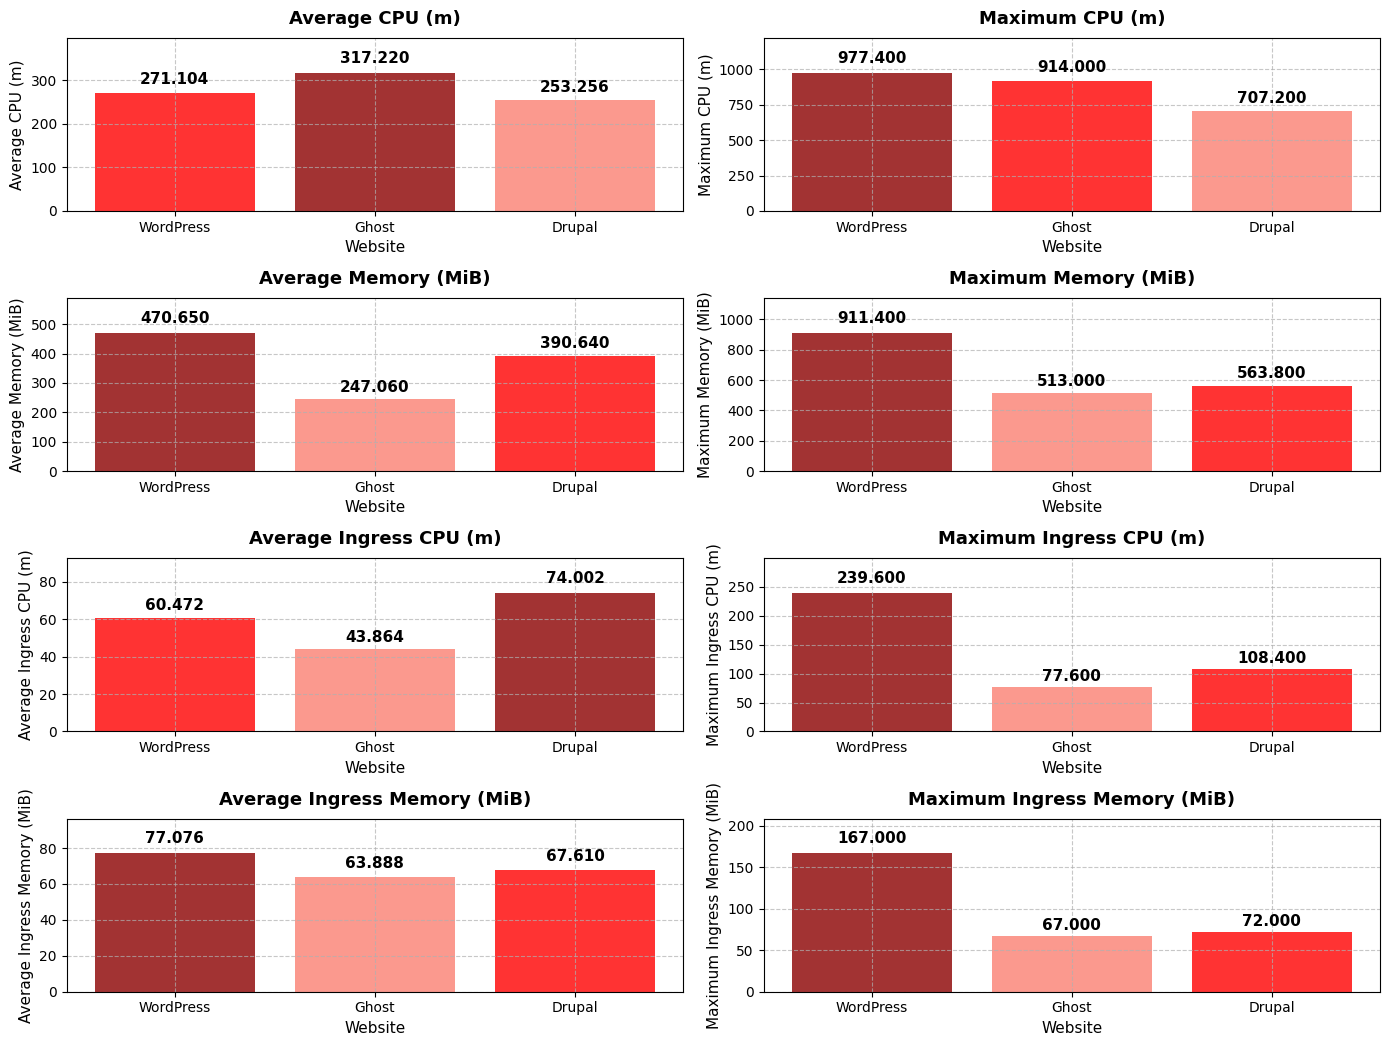

In [9]:
fig, axs = plt.subplots(4, 2, figsize=(14, 11))

metrics = [
    ('Avg CPU (m)',             'Average CPU (m)'              ),
    ('Max CPU (m)',             'Maximum CPU (m)'              ),
    ('Avg Memory (Mi)',         'Average Memory (MiB)'         ),
    ('Max Memory (Mi)',         'Maximum Memory (MiB)'         ),
    ('Avg Ingress CPU (m)',     'Average Ingress CPU (m)'      ),
    ('Max Ingress CPU (m)',     'Maximum Ingress CPU (m)'      ),
    ('Avg Ingress Memory (Mi)', 'Average Ingress Memory (MiB)' ),
    ('Max Ingress Memory (Mi)', 'Maximum Ingress Memory (MiB)' ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 2)

    values = result_monitoring[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]
        
    bars = axs[row, col_idx].bar(result_monitoring['Website'], result_monitoring[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = result_monitoring[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.25)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Assets Testing/Incremental/Inject Cache/Comparison Result - Incremental Inject.png")
plt.show()

In [10]:
wordpress_kernel    = "Wordpress Summary/IncrementalTesting/InjectCache/Wordpress Kernel - Incremental Inject Summary.csv"
ghost_kernel = "Ghost Summary/IncrementalTesting/InjectCache/Ghost Kernel - Incremental Inject Summary.csv"
drupal_kernel = "Drupal Summary/IncrementalTesting/InjectCache/Drupal Kernel - Incremental Inject Summary.csv"

wordpress_kernel_monitor = pd.read_csv(wordpress_kernel)
ghost_kernel_monitor = pd.read_csv(ghost_kernel)
drupal_kernel_monitor = pd.read_csv(drupal_kernel)

In [11]:
wordpress_kernel_monitoring = wordpress_kernel_monitor.iloc[-1:].copy()
ghost_kernel_monitoring = ghost_kernel_monitor.iloc[-1:].copy()
drupal_kernel_monitoring = drupal_kernel_monitor.iloc[-1:].copy()

wordpress_kernel_monitoring['Website'] = 'WordPress'
ghost_kernel_monitoring['Website'] = 'Ghost'
drupal_kernel_monitoring['Website'] = 'Drupal'

kernel_comparison = pd.concat([wordpress_kernel_monitoring, ghost_kernel_monitoring, drupal_kernel_monitoring], ignore_index=True)

In [12]:
cols_kernel_monitoring = ['Website', 'Avg CPU (%)', 'Max CPU (%)', 'Avg Memory (MB)', 'Max Memory (MB)', 'Avg I/O (S)', 'Max I/O (S)', 'Context Switches']

kernel_monitoring = kernel_comparison[cols_kernel_monitoring].round(3)
kernel_monitoring.to_csv("Assets Testing/Incremental/Inject Cache/Comparison Kernel - Incremental Inject.csv", index=False)

styled = (kernel_monitoring.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

Website,Avg CPU (%),Max CPU (%),Avg Memory (MB),Max Memory (MB),Avg I/O (S),Max I/O (S),Context Switches
WordPress,83.594,101.000,2945.456,4217.800,5006.666,55664.000,29180.502
Ghost,88.392,101.000,3922.812,4366.400,1060.406,12769.600,21073.616
Drupal,65.570,95.200,3634.520,4189.400,1448.178,8761.630,27306.848


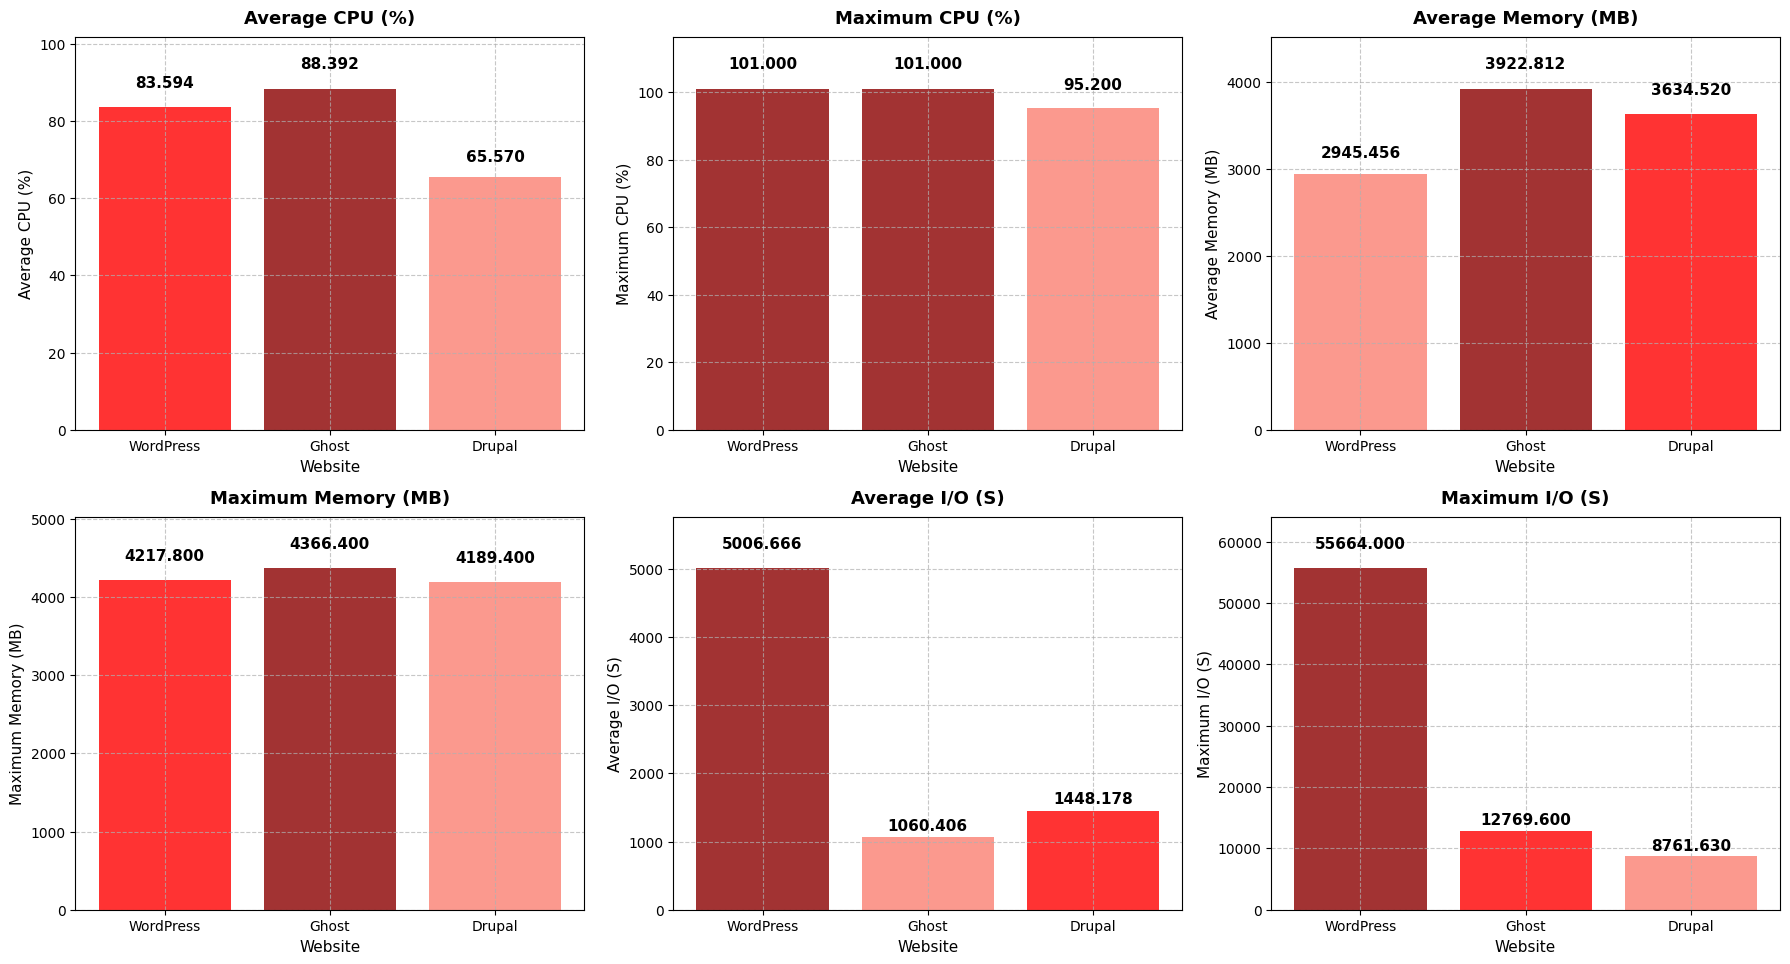

In [13]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

metrics = [
    ('Avg CPU (%)',     'Average CPU (%)'     ),
    ('Max CPU (%)',     'Maximum CPU (%)'     ),
    ('Avg Memory (MB)', 'Average Memory (MB)' ),
    ('Max Memory (MB)', 'Maximum Memory (MB)' ),
    ('Avg I/O (S)',     'Average I/O (S)'     ), 
    ('Max I/O (S)',     'Maximum I/O (S)'     ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 3)

    values = kernel_monitoring[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]

    bars = axs[row, col_idx].bar(kernel_monitoring['Website'], kernel_monitoring[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = kernel_monitoring[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Assets Testing/Incremental/Inject Cache/Comparison Kernel - Incremental Inject.png")
plt.show()